In [1]:
# K-Means Clustering

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

# Use first two features for visualization
X = iris.data[:, :2]

# Number of clusters
k = 3


# ---------------------------------------------------------
# 1. Initialize centroids
# ---------------------------------------------------------
def initialize_centroids(X, k, random_state=42):
    np.random.seed(random_state)

    indices = np.random.choice(
        len(X),
        k,
        replace=False
    )

    return X[indices].copy()


# ---------------------------------------------------------
# 2. Calculate Euclidean distances
# ---------------------------------------------------------
def calculate_distances(X, centroids):
    distances = np.sqrt(
        (
            X[:, np.newaxis, :]
            - centroids[np.newaxis, :, :]
        ) ** 2
    ).sum(axis=2)

    return distances


# ---------------------------------------------------------
# 3. Assign points to nearest centroid
# ---------------------------------------------------------
def assign_clusters(X, centroids):

    distances = calculate_distances(
        X,
        centroids
    )

    return np.argmin(
        distances,
        axis=1
    )


# ---------------------------------------------------------
# 4. Update centroids
# ---------------------------------------------------------
def update_centroids(
    X,
    labels,
    k,
    old_centroids
):

    new_centroids = np.zeros_like(
        old_centroids
    )

    for i in range(k):

        cluster_points = X[
            labels == i
        ]

        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(
                cluster_points,
                axis=0
            )
        else:
            new_centroids[i] = old_centroids[i]

    return new_centroids


# ---------------------------------------------------------
# 5. K-Means algorithm
# ---------------------------------------------------------
def kmeans(
    X,
    k,
    max_iterations=100,
    tolerance=1e-4
):

    # Initialize centroids
    centroids = initialize_centroids(
        X,
        k
    )

    for iteration in range(
        max_iterations
    ):

        # Assign clusters
        labels = assign_clusters(
            X,
            centroids
        )

        # Update centroids
        new_centroids = update_centroids(
            X,
            labels,
            k,
            centroids
        )

        # Calculate centroid movement
        centroid_shift = np.linalg.norm(
            new_centroids - centroids
        )

        # Update centroids
        centroids = new_centroids

        # Check convergence
        if centroid_shift < tolerance:

            print(
                "K-Means converged at iteration:",
                iteration + 1
            )

            break

    return centroids, labels


# ---------------------------------------------------------
# Run K-Means
# ---------------------------------------------------------
centroids, labels = kmeans(
    X,
    k
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------
print("\nFinal Centroids:")
print(centroids)

print("\nFirst 20 Cluster Labels:")
print(labels[:20])

K-Means converged at iteration: 6

Final Centroids:
[[5.96140351 2.8       ]
 [5.         3.3       ]
 [6.93783784 3.08648649]]

First 20 Cluster Labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1]


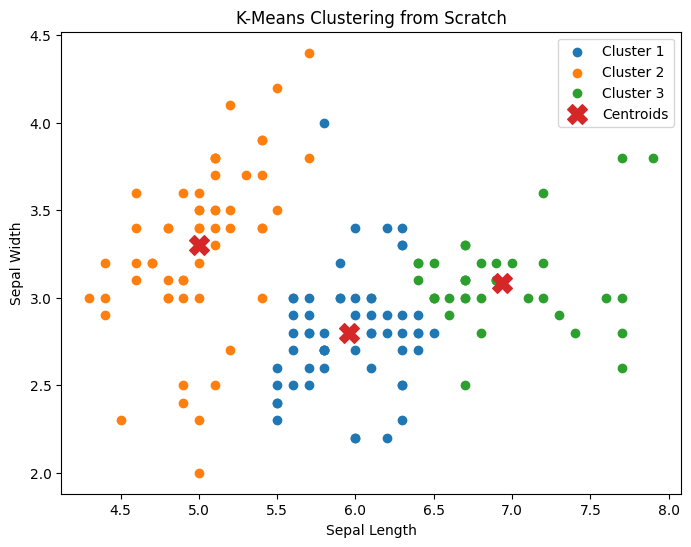

In [3]:
# Visualization

plt.figure(figsize=(8, 6))

for cluster in range(len(centroids)):

    points = X[labels == cluster]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        label=f"Cluster {cluster + 1}"
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering from Scratch")
plt.legend()
plt.show()

In [4]:
# Linear Discriminant Analysis

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Dataset shape: (150, 4)
Number of classes: 3


In [6]:
classes = np.unique(y)

overall_mean = np.mean(X, axis=0)

class_means = {}

for c in classes:
    class_means[c] = np.mean(X[y == c], axis=0)

print("Overall Mean:")
print(overall_mean)

print("\nClass Means:")
for c in classes:
    print(f"Class {c}:", class_means[c])

Overall Mean:
[5.84333333 3.05733333 3.758      1.19933333]

Class Means:
Class 0: [5.006 3.428 1.462 0.246]
Class 1: [5.936 2.77  4.26  1.326]
Class 2: [6.588 2.974 5.552 2.026]


In [7]:
n_features = X.shape[1]

SW = np.zeros((n_features, n_features))

for c in classes:

    class_data = X[y == c]
    mean_c = class_means[c]

    for sample in class_data:
        sample = sample.reshape(-1, 1)
        mean_vector = mean_c.reshape(-1, 1)

        SW += (sample - mean_vector) @ (
            sample - mean_vector
        ).T

print("Within-Class Scatter Matrix (SW):")
print(SW)

Within-Class Scatter Matrix (SW):
[[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]


In [8]:
SB = np.zeros((n_features, n_features))

for c in classes:

    class_data = X[y == c]
    n_c = len(class_data)

    mean_c = class_means[c]

    mean_diff = (
        mean_c - overall_mean
    ).reshape(-1, 1)

    SB += n_c * (mean_diff @ mean_diff.T)

print("Between-Class Scatter Matrix (SB):")
print(SB)

Between-Class Scatter Matrix (SB):
[[ 63.21213333 -19.95266667 165.2484      71.27933333]
 [-19.95266667  11.34493333 -57.2396     -22.93266667]
 [165.2484     -57.2396     437.1028     186.774     ]
 [ 71.27933333 -22.93266667 186.774       80.41333333]]


In [9]:
# Use pseudo-inverse for numerical stability
SW_inverse = np.linalg.pinv(SW)

matrix = SW_inverse @ SB

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(matrix)

# Convert small numerical imaginary parts to real values
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print("Eigenvalues:")
print(eigenvalues)

Eigenvalues:
[ 3.21919292e+01  2.85391043e-01  8.38270887e-15 -5.67199370e-15]


In [10]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:")
print(eigenvalues)

print("\nSorted Eigenvectors:")
print(eigenvectors)

Sorted Eigenvalues:
[ 3.21919292e+01  2.85391043e-01  8.38270887e-15 -5.67199370e-15]

Sorted Eigenvectors:
[[-0.20874182  0.00653196 -0.62505911 -0.53587101]
 [-0.38620369  0.58661055 -0.03272339  0.4441958 ]
 [ 0.55401172 -0.25256154 -0.09855506  0.48642657]
 [ 0.7073504   0.76945309  0.77363892 -0.52813024]]


In [11]:
# Number of LDA components
n_components = len(classes) - 1

W = eigenvectors[:, :n_components]

print("Selected LDA Projection Matrix:")
print(W)

Selected LDA Projection Matrix:
[[-0.20874182  0.00653196]
 [-0.38620369  0.58661055]
 [ 0.55401172 -0.25256154]
 [ 0.7073504   0.76945309]]


In [12]:
# Project data onto selected LDA components
X_lda = X @ W

print("Original shape:", X.shape)
print("LDA shape:", X_lda.shape)

Original shape: (150, 4)
LDA shape: (150, 2)


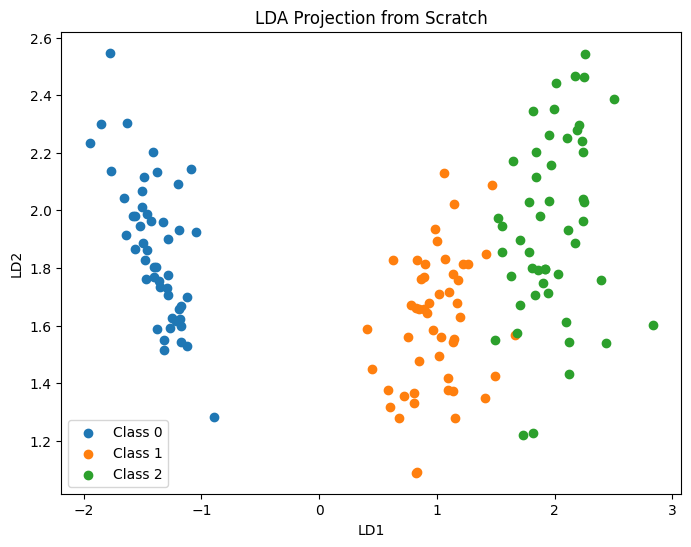

In [13]:
# Visualization of LDA projection

plt.figure(figsize=(8, 6))

for c in classes:

    plt.scatter(
        X_lda[y == c, 0],
        X_lda[y == c, 1],
        label=f"Class {c}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection from Scratch")
plt.legend()
plt.show()